In [2]:
import numpy as np
import matplotlib.pyplot as plt

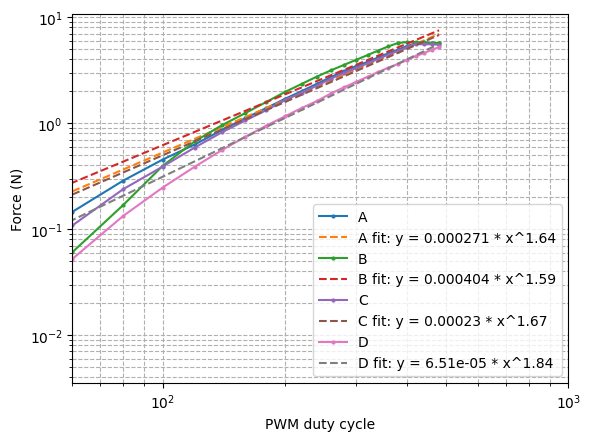

In [9]:
# plot A B C D

datasets = ["A", "B", "C", "D"]


for dataset in datasets:
    try:
        with open(f"{dataset}.txt", "r") as f:
            data = f.read().splitlines()
    except FileNotFoundError:
        print(f"File {dataset}.txt not found")
        continue

    speedlist = []
    forcelist = []

    for line in data:
        speedraw, forceraw = line.split(',')
        speedstr = speedraw.split(':')[1].strip()
        forcestr = forceraw.split(':')[1].strip()

        speed = float(speedstr)
        force = float(forcestr)

        speedlist.append(speed)
        forcelist.append(force)
    
    plt.loglog(speedlist, forcelist, label=dataset, marker='o', markersize=2)
    # plot linear fit line
    speedlist = np.array(speedlist)
    speedlist_f = speedlist[100 < speedlist]
    x = np.log10(speedlist_f)
    forcelist = np.array(forcelist)
    forcelist_f = forcelist[100 < speedlist]
    y = np.log10(forcelist_f)

    n, log_A = np.polyfit(x, y, 1)
    A = 10**log_A
    plt.loglog(speedlist, A * speedlist**n, linestyle='--', label=f"{dataset} fit: y = {A:.3g} * x^{n:.2f}")

plt.xlim(60, 1e3)

plt.xlabel("PWM duty cycle")
plt.ylabel("Force (N)")

plt.grid(which='both', linestyle='--')
plt.legend()
plt.show()

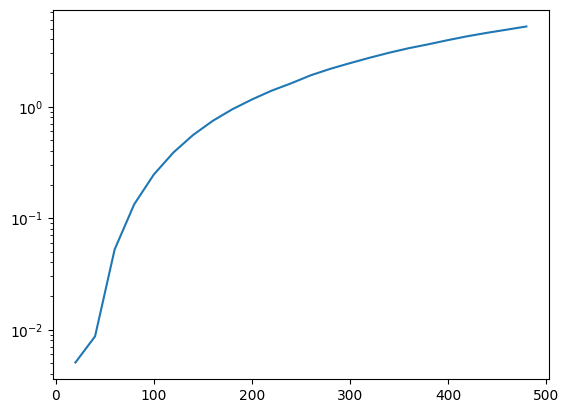

In [7]:

# plot log thrust vs speed

